In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.notebook_setup import setup
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from scripts.kaysons_visual_config import * # Kayson's file. 

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings

env = setup()

import numpy as np
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
import networkx as nx
from netgraph import Graph
import matplotlib.pyplot as plt
from pypalettes import load_cmap

from pypalettes import load_cmap
cmap = load_cmap("Aurora")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from netgraph import Graph
from networkx.algorithms import community



Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots


In [25]:
# df_energy = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv")
# df_portrait = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/summary_indiv_portrait_for_exp_76_90000_samples_animal_206.csv")
experiment_name = "05_second_big_overnight_run_10201"
df_energy = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/{experiment_name}/summary_indiv_energies_for_exp_{experiment_name}.csv")
df_portrait = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/{experiment_name}/summary_indiv_portrait_for_exp_{experiment_name}.csv")

In [20]:
len(df_portrait), len(df_energy)

(10201, 10201)

In [ ]:
# df_portrait = df_portrait[:30000]
# df_energy = df_energy[:30000]

Saved figure to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/plots/correlating_energy_and_f1_05_second_big_overnight_run_10201.pdf


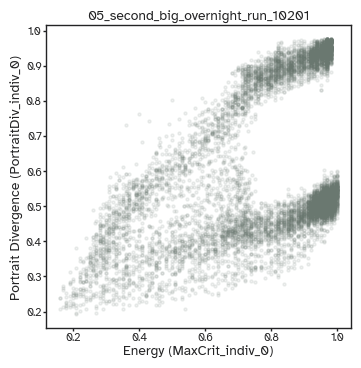

In [30]:
plt.figure(figsize=(viz.cm_to_inch((10, 10))))
plt.scatter(df_energy['MaxCrit_indiv_0'], df_portrait['PortraitDiv_indiv_0'], alpha=0.1, s=5)
plt.xlabel("Energy (MaxCrit_indiv_0)")
plt.ylabel("Portrait Divergence (PortraitDiv_indiv_0)")
plt.title(experiment_name)
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/drafts_and_one_time_plots/plots/correlating_energy_and_f1_{experiment_name}.pdf")
plt.savefig(save_path)
print(f"Saved figure to {save_path}")

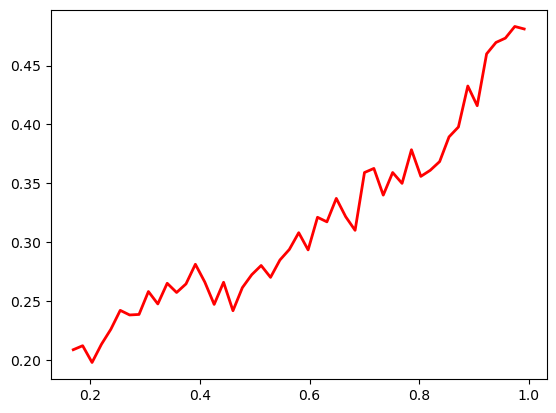

In [16]:
# Binned minimum approach
bins = np.linspace(df_energy['MaxCrit_indiv_0'].min(), 
                   df_energy['MaxCrit_indiv_0'].max(), 50)
bin_indices = np.digitize(df_energy['MaxCrit_indiv_0'], bins)

min_values = []
bin_centers = []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if mask.sum() > 0:
        min_values.append(df_portrait.loc[mask, 'PortraitDiv_indiv_0'].quantile(0.05))
        bin_centers.append(bins[i-1:i+1].mean())

# Plot the envelope
plt.plot(bin_centers, min_values, 'r-', linewidth=2, label='5th percentile envelope')